In [1]:
# All Newman-alpha-scheme machinery (centering, Jacobians, LCF/spectral-gap
# computation, sync/async updates, MLE fitting, SBM data generation) now
# lives in utils.py -- see that file for full documentation of each function.
# utils.py must be in the same directory as this notebook (or on sys.path).
from utils import *

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import to_rgb, to_hex
from matplotlib.lines import Line2D

# Evaluation data

In [2]:
# ── Load ASSISTments 2009-2010 skill builder (corrected) ──
df = pd.read_csv('data/skill_builder_data.csv', encoding='ISO-8859-15', low_memory=False)

print(f"Raw shape: {df.shape}")
print(f"Missing skill_id: {df['skill_id'].isna().mean():.3f}")

# ── Drop rows with missing skill_id ──
df = df.dropna(subset=['skill_id']).copy()

# ── Remove multi-skill duplicate rows (same order_id appearing >1 time) ──
dupe_mask = df.duplicated(subset=['order_id'], keep=False)
print(f"Rows involved in order_id duplicates (multi-skill): {dupe_mask.sum()} of {len(df)}")
df = df[~dupe_mask].copy()

print(f"After removing multi-skill duplicates: {df.shape}")
print(f"Unique students: {df['user_id'].nunique()},  Unique problems: {df['problem_id'].nunique()}")

# ── Keep only what's needed; no skill filtering ──
df = df[['user_id', 'problem_id', 'correct']].dropna()
df['correct'] = df['correct'].astype(int)

# ── Iteratively enforce: every student has >=k responses, every problem has >=k responses ──
k = 30
prev_len = -1
while len(df) != prev_len:
    prev_len = len(df)
    user_counts = df['user_id'].value_counts()
    item_counts = df['problem_id'].value_counts()
    valid_users = user_counts[user_counts >= k].index
    valid_items = item_counts[item_counts >= k].index
    df = df[df['user_id'].isin(valid_users) & df['problem_id'].isin(valid_items)]

print(f"\nAfter enforcing k={k} min responses per student/problem: {len(df)} rows remain")
print(f"Students remaining: {df['user_id'].nunique()},  Problems remaining: {df['problem_id'].nunique()}")

# ── Remap IDs to consecutive 0-indexed integers (items first) ──
user_ids = sorted(df['user_id'].unique())
item_ids = sorted(df['problem_id'].unique())
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {p: j for j, p in enumerate(item_ids)}

n_users = len(user_ids)
n_items = len(item_ids)
print(f"n_users = {n_users}, n_items = {n_items}")

# ── Build bipartite comparison matrix W, items first ──
n_full = n_items + n_users
W_full = np.zeros((n_full, n_full))

user_nodes = n_items + df['user_id'].map(user_to_idx).to_numpy()
item_nodes = df['problem_id'].map(item_to_idx).to_numpy()
correct    = df['correct'].to_numpy()

np.add.at(W_full, (user_nodes[correct == 1], item_nodes[correct == 1]), 1)  # student beats problem
np.add.at(W_full, (item_nodes[correct == 0], user_nodes[correct == 0]), 1)  # problem beats student

# ── Restrict to largest strongly connected component ──
G = nx.from_numpy_array(W_full, create_using=nx.DiGraph)
largest_scc = max(nx.strongly_connected_components(G), key=len)
idx = sorted(largest_scc)

W = W_full[np.ix_(idx, idx)]
n = W.shape[0]
is_item = np.array([k_ < n_items for k_ in idx])

print(f"\nAfter SCC trim: n = {n}  ({is_item.sum()} items, {(~is_item).sum()} persons)")
print(f"Total comparisons: {int(W.sum())}")

win_list  = {i: [np.where(W[i]  > 0)[0], W[i]  [W[i]   > 0]] for i in range(n)}
loss_list = {i: [np.where(W[:,i]> 0)[0], W[:,i][W[:,i]  > 0]] for i in range(n)}

Raw shape: (346860, 31)
Missing skill_id: 0.184
Rows involved in order_id duplicates (multi-skill): 0 of 283105
After removing multi-skill duplicates: (283105, 31)
Unique students: 4163,  Unique problems: 17751

After enforcing k=30 min responses per student/problem: 52424 rows remain
Students remaining: 529,  Problems remaining: 1034
n_users = 529, n_items = 1034

After SCC trim: n = 1545  (1020 items, 525 persons)
Total comparisons: 51788


In [3]:
mle = newman_fpi(win_list, loss_list, alpha = 0, sync = 'none')

Converged in 59 iterations (l2 error = 7.756e-16).


In [4]:
def population_W(W, pi):
    # Expected comparison matrix under BT, counts inferred from W.
    # bar_W[i,j] = (W[i,j]+W[j,i]) * pi[i]/(pi[i]+pi[j]).
    pi = np.asarray(pi, dtype=float)
    N  = W + W.T                                      # total comparisons per edge
    P  = pi[:, None] / (pi[:, None] + pi[None, :])    # pi_i / (pi_i + pi_j)
    bar_W = N * P
    np.fill_diagonal(bar_W, 0)
    return bar_W

bar_W   = population_W(W, mle)
rel_err = np.linalg.norm(W - bar_W, ord=2) / np.linalg.norm(W, ord=2)
print(f"||W - bar_W||_2 / ||W||_2 = {rel_err:.6f}")

||W - bar_W||_2 / ||W||_2 = 0.188453


In [13]:
alpha_set = np.linspace(0,1,20)

rates_f = np.array([get_lcf(W, mle, alpha, sync = 'full') for alpha in alpha_set])
gaps_f = np.array([get_gap(W, mle, alpha, sync = 'full') for alpha in alpha_set])

rates_a = np.array([get_lcf(W, mle, alpha, sync = 'none') for alpha in alpha_set])
gaps_a = np.array([get_gap(W, mle, alpha, sync = 'none') for alpha in alpha_set])

In [14]:
print("Sync:")
print(f"  rho(0)     = {get_lcf(W, mle, 0, sync='full'):.6f},  rho_bar(0) = {1 - get_gap(W, mle, 0, 'full'):.6f}")
print(f"  rho(1)     = {get_lcf(W, mle, 1, sync='full'):.6f},  rho_bar(1) = {1 - get_gap(W, mle, 1, 'full'):.6f}")

print("Async:")
print(f"  rho(0)     = {get_lcf(W, mle, 0, sync='none'):.6f},  rho_bar(0) = {1 - get_gap(W, mle, 0, 'none'):.6f}")
print(f"  rho(1)     = {get_lcf(W, mle, 1, sync='none'):.6f},  rho_bar(1) = {1 - get_gap(W, mle, 1, 'none'):.6f}")

Sync:
  rho(0)     = 1.011964,  rho_bar(0) = 1.000000
  rho(1)     = 0.968262,  rho_bar(1) = 0.968262
Async:
  rho(0)     = 0.563532,  rho_bar(0) = 0.557942
  rho(1)     = 0.968254,  rho_bar(1) = 0.968254


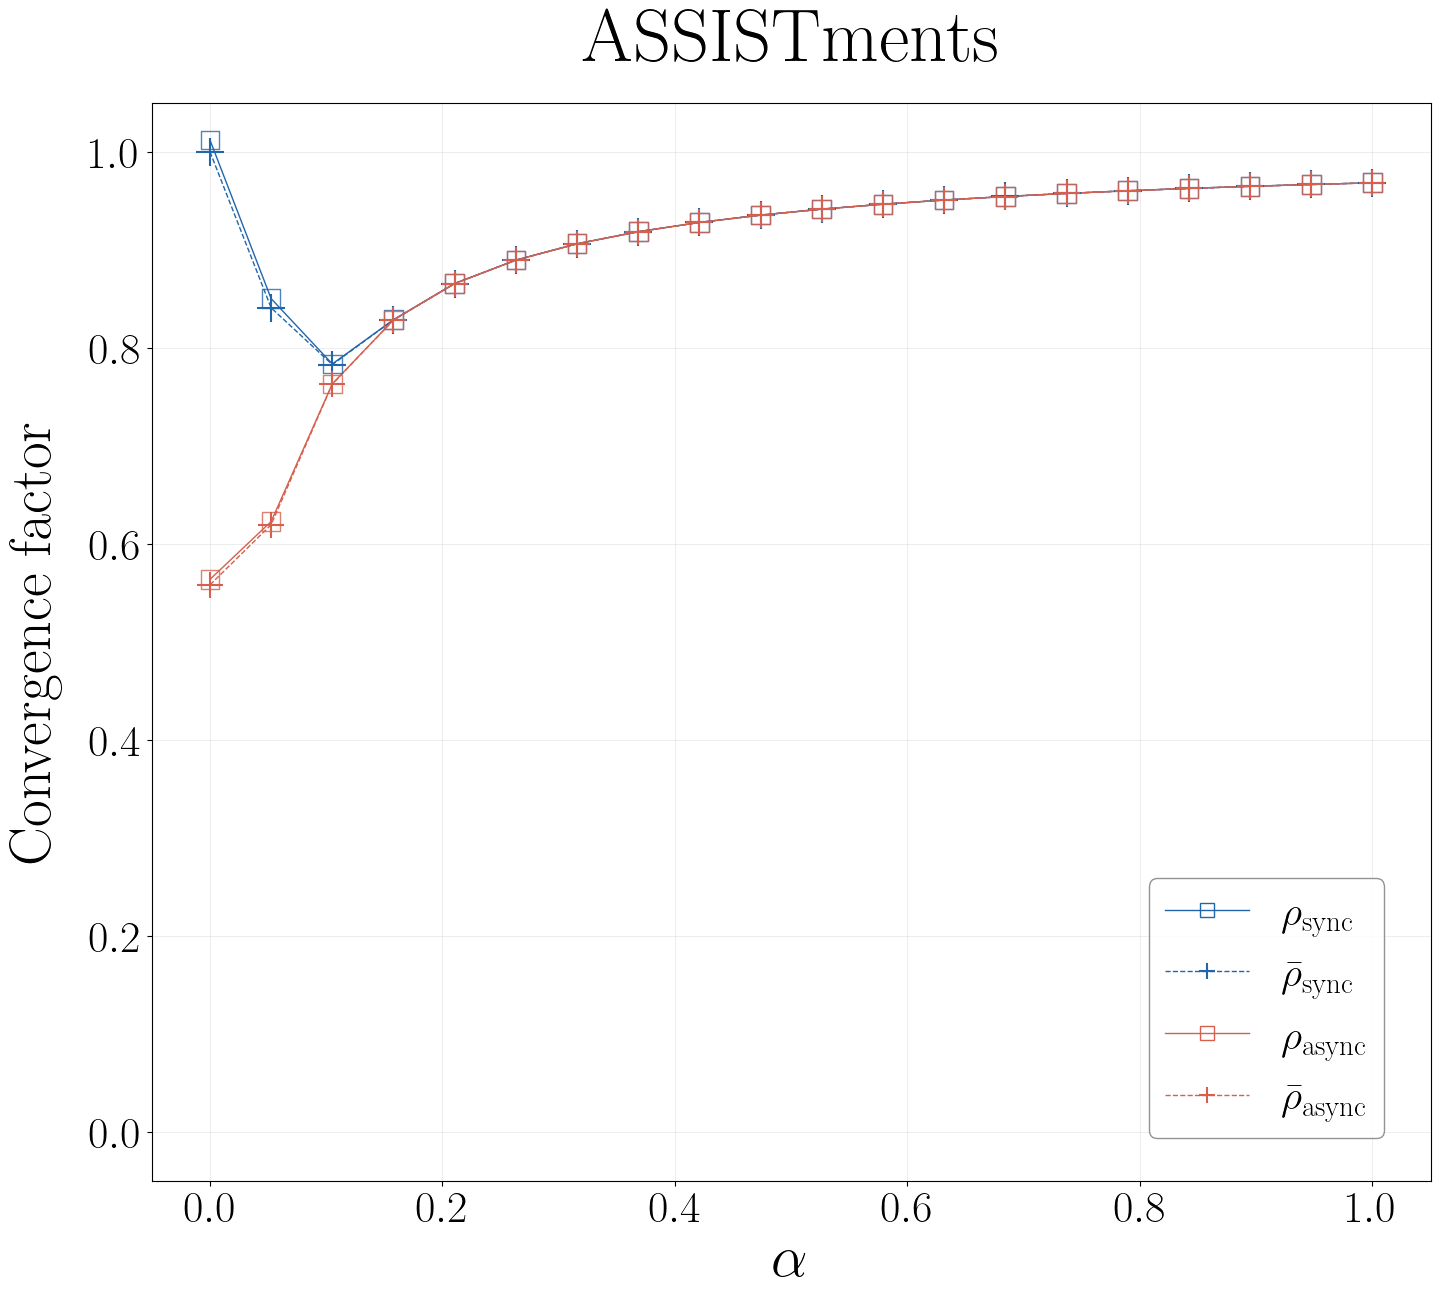

In [15]:
# --- Shared style config ---
FIG_W, FIG_H  = 16.5, 14
TITLE_FS      = 54
LABEL_FS      = 42
TICK_FS       = 32
LEGEND_FS     = 30
MARKER_S      = 180
CI_ALPHA      = 0.15

COLOR_SYNC    = '#2166AC'
COLOR_ASYNC   = '#D6604D'

rc('text', usetex=True)
rc('font', family='serif')
rc('axes', linewidth=0.8)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

# Convergence rates -- square markers
ax.scatter(alpha_set, rates_f, label=r'$\rho_{\mathrm{sync}}$',
                color=COLOR_SYNC,  s=MARKER_S,   marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_f, color=COLOR_SYNC, linewidth=1, zorder=2)

ax.scatter(alpha_set, 1 - gaps_f, label=r'$\bar\rho_{\mathrm{sync}}$',
        color=COLOR_SYNC,  s=MARKER_S*2 + 40, marker='+', linewidths=1.5, zorder=3)
ax.plot(alpha_set, 1 - gaps_f, color=COLOR_SYNC, linewidth=1, linestyle='--', zorder=2)

# Gap predictions -- plus markers
ax.scatter(alpha_set, rates_a, label=r'$\rho_{\mathrm{async}}$',
        color=COLOR_ASYNC, s=MARKER_S,   marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_a, color=COLOR_ASYNC, linewidth=1, zorder=2)

ax.scatter(alpha_set, 1 - gaps_a, label=r'$\bar\rho_{\mathrm{async}}$',
        color=COLOR_ASYNC, s=MARKER_S*2, marker='+', linewidths=1.5, zorder=3)
ax.plot(alpha_set, 1 - gaps_a, color=COLOR_ASYNC, linewidth=1, linestyle='--', zorder=2)


legend_elements = [
            Line2D([0,1], [0,0], color=COLOR_SYNC,  marker='s', markersize=10,
                markerfacecolor='none', markeredgecolor=COLOR_SYNC,
                linestyle='-',  linewidth=1, label=r'$\rho_{\mathrm{sync}}$'),
            Line2D([0,1], [0,0], color=COLOR_SYNC,  marker='+', markersize=12,
                markeredgewidth=1.5,
                linestyle='--', linewidth=1, label=r'$\bar\rho_{\mathrm{sync}}$'),
            Line2D([0,1], [0,0], color=COLOR_ASYNC, marker='s', markersize=10,
                markerfacecolor='none', markeredgecolor=COLOR_ASYNC,
                linestyle='-',  linewidth=1, label=r'$\rho_{\mathrm{async}}$'),
            Line2D([0,1], [0,0], color=COLOR_ASYNC, marker='+', markersize=12,
                markeredgewidth=1.5,
                linestyle='--', linewidth=1, label=r'$\bar\rho_{\mathrm{async}}$'),
        ]


ax.set_title(r"$\mathrm{ASSISTments}$", fontsize=TITLE_FS, color='black', pad=30)
ax.set_xlabel(r'$\alpha$', fontsize=LABEL_FS)
# --- Referee comment: unify y-axis label from 'Rate' to 'Convergence factor' ---
ax.set_ylabel(r'Convergence factor', fontsize=LABEL_FS, labelpad=20)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, linewidth=0.4, alpha=0.4)

ax.legend(handles=legend_elements, fontsize=LEGEND_FS, loc='lower right',
          bbox_to_anchor=(0.98, 0.02), framealpha=0.85, edgecolor='gray')

# plt.tight_layout(pad=0.5)
plt.savefig("math_rates.pdf")
plt.show()
plt.close()

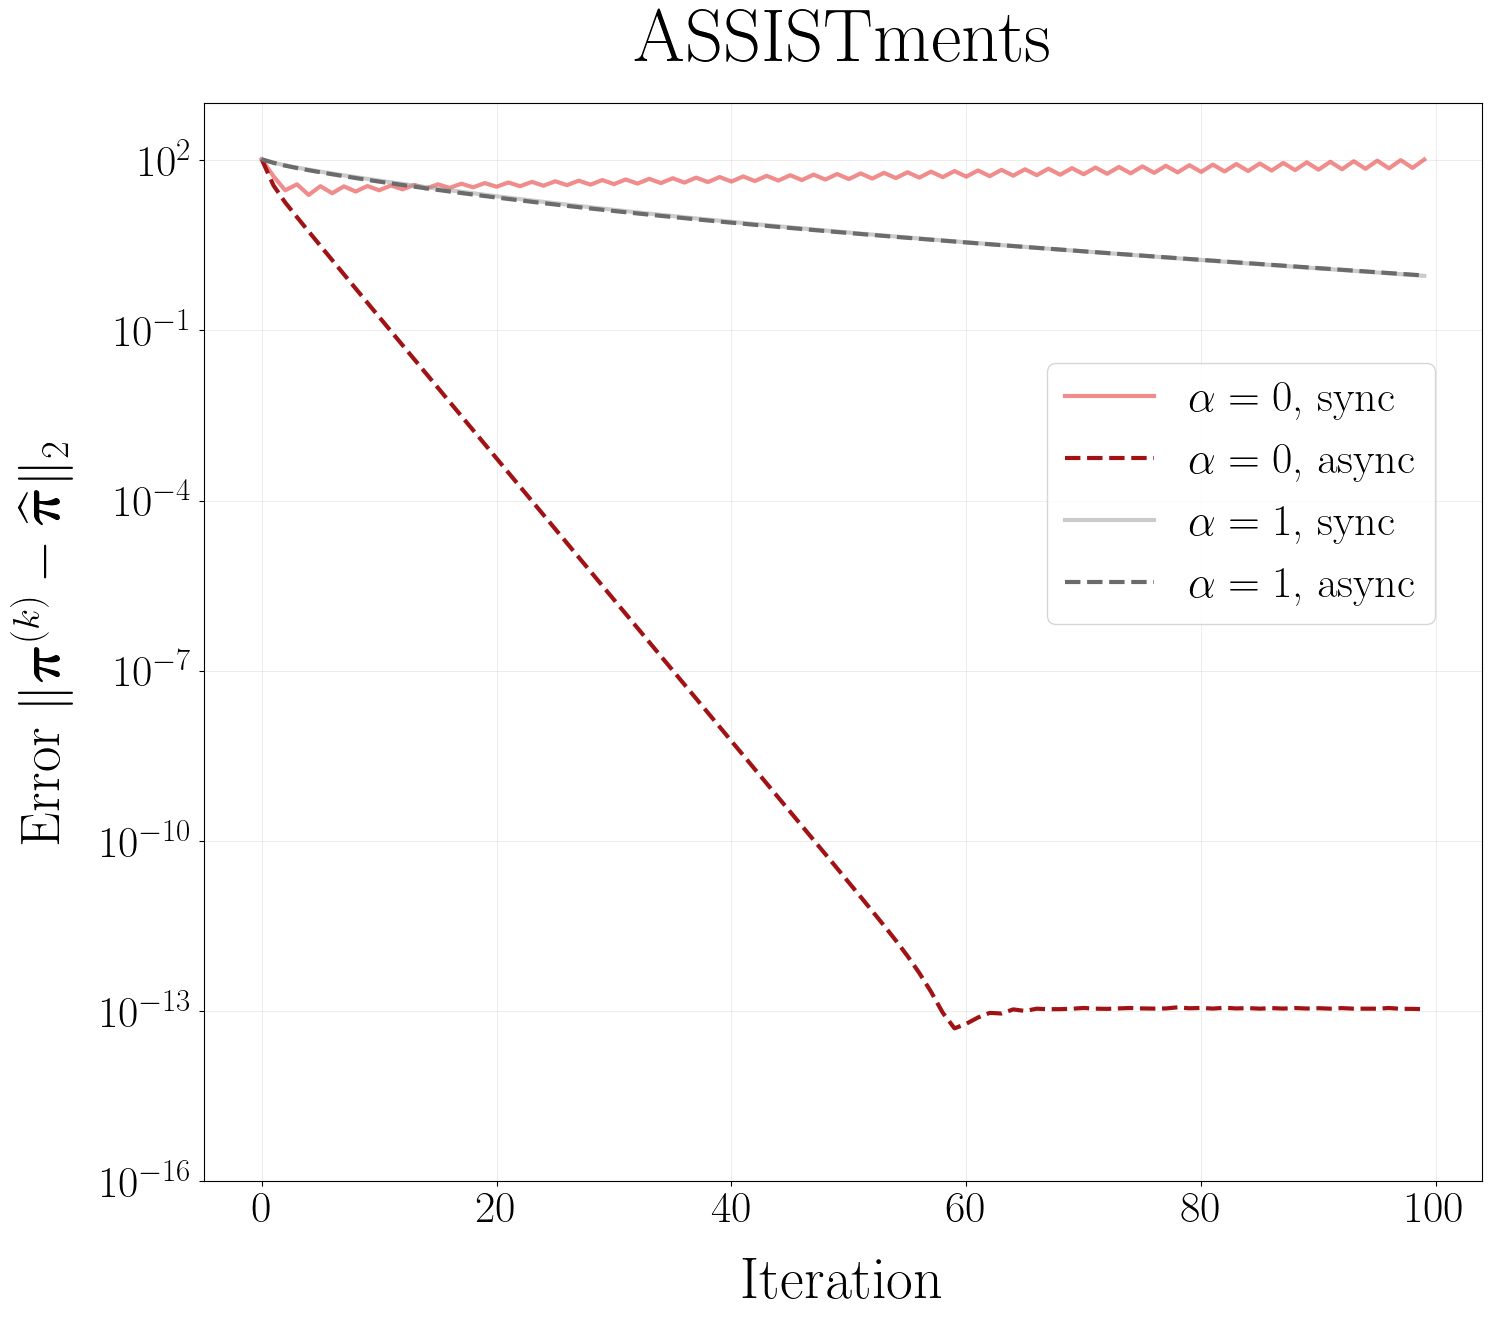

In [6]:
N = 100
alphas = [0, 1]
base_colors = plt.cm.Set1(np.linspace(0, 1, len(alphas)))  # base color per alpha

def shade_color(color, factor):
    # lighter/darker shade of color (factor <1 darker, >1 lighter)
    r, g, b = to_rgb(color)
    r = min(max(r*factor,0),1)
    g = min(max(g*factor,0),1)
    b = min(max(b*factor,0),1)
    return (r, g, b)

rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below
plt.figure(figsize=(16.5, 14))

for i, a in enumerate(alphas):
    gamma = np.ones(n)

    sync = 'full'
    error_sync = []
    for _ in range(N):
        error_sync.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync=sync)
    plt.semilogy(error_sync,
                 color=base_colors[i], linewidth=3, linestyle='-', alpha=0.5,
                 label=rf"$\alpha={a}$, sync")

    sync = 'none'
    gamma = np.ones(n)
    error_async = []
    for _ in range(N):
        error_async.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync=sync)
    plt.semilogy(np.maximum(error_async, 5e-14),
                 color=shade_color(base_colors[i], 0.7), linewidth=3, linestyle='--',
                 label=rf"$\alpha={a}$, async")

plt.title(r"$\mathrm{ASSISTments}$", fontsize=54, color='black', pad=30)
plt.ylim(1e-16, 1e3)
plt.xlabel(r'Iteration', fontsize=42, labelpad=20)
# --- Referee comment: unify y-axis label across figures ---
plt.ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=40, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=32)
plt.grid(True, linewidth=0.4, alpha=0.4)
plt.legend(fontsize=32, loc='upper right', bbox_to_anchor=(0.98, 0.78))
plt.savefig("math.pdf")
plt.show()

In [ ]:
ff1 = get_slope_average(win_list, loss_list, mle, 0, sync = 'full', tol = 1e-10, maxiter = 10000, N = 10)
gg1 = get_slope_average(win_list, loss_list, mle, 0, sync = 'none', tol = 1e-10, maxiter = 10000, N = 10)
gg2 = get_slope_average(win_list, loss_list, mle, 1, sync = 'full', tol = 1e-10, maxiter = 10000, N = 10)
print(np.log10(ff1[0])/np.log10(gg2[0]), np.log10(gg1[0])/np.log10(gg2[0]))

In [ ]:
print(np.log10(1-get_gap(W, mle, alpha = 0, sync = 'full'))/np.log10(1-get_gap(W, mle, alpha = 1, sync = 'full')), \
      np.log10(1-get_gap(W, mle, alpha = 0, sync = 'none'))/np.log10(1-get_gap(W, mle, alpha = 1, sync = 'full')))